# Phase 1: Exploratory Data Analysis

Exploring three datasets from the NESO Data Portal and Carbon Intensity API:
1. **Generation Mix** - hourly generation by fuel type + carbon intensity (2009-present, 302K records)
2. **Historic Demand** - half-hourly national demand + embedded renewables (2020-2025, 105K records)
3. **Carbon Intensity** - half-hourly forecast vs actual carbon intensity (2024-present, 39K records)

## Research Questions

1. Can we accurately predict next-day peak electricity demand using historical patterns and temporal features?
2. What features (time-based, weather, generation mix) are most predictive of demand?
3. Can a RAG pipeline over NESO/Ofgem reports provide meaningful context for demand anomalies?
4. How has the UK energy transition (coal phase-out, wind/solar growth) affected demand forecasting difficulty?

## EDA Goals
- Understand data quality (missing values, date gaps, outliers)
- Identify temporal patterns (daily, weekly, seasonal)
- Spot anomalies worth investigating with the RAG pipeline later
- Decide which features to use for demand forecasting

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

DATA_RAW = Path('../data/raw')

## 1. Generation Mix

In [21]:
gen = pd.read_csv(DATA_RAW / 'generation_mix.csv')
gen['DATETIME'] = pd.to_datetime(gen['DATETIME'])
gen = gen.sort_values('DATETIME').reset_index(drop=True)

print(f'Shape: {gen.shape}')
print(f'Date range: {gen["DATETIME"].min()} to {gen["DATETIME"].max()}')
print(f'\nMissing values:')
print(gen.isnull().sum()[gen.isnull().sum() > 0])
gen.head()

Shape: (301956, 35)
Date range: 2009-01-01 00:00:00 to 2026-03-23 17:30:00

Missing values:
Series([], dtype: int64)


,_id,DATETIME,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
0,1,2009-01-01 00:00:00,8367.0,15037.0,7099.0,248.0,62.0,246.0,2518.0,0.0,...,7.5,0.0,0.0,0.0,0.0,100.0,22.8,24.5,1.7,69.7
1,2,2009-01-01 00:30:00,8495.0,15095.0,7088.0,229.0,57.0,245.0,2495.0,0.0,...,7.4,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.6,70.0
2,3,2009-01-01 01:00:00,8471.0,15088.0,7074.0,207.0,52.0,246.0,2465.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.2,1.5,70.1
3,4,2009-01-01 01:30:00,8318.0,15035.0,7064.0,191.0,48.0,246.0,2439.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.5,70.0
4,5,2009-01-01 02:00:00,8295.0,15005.0,7052.0,175.0,44.0,246.0,2363.0,0.0,...,7.1,0.0,0.0,0.0,0.0,100.0,22.7,24.3,1.4,70.2


In [22]:
gen.describe()

,_id,DATETIME,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
count,3.019560e+05,301956,301956.000000,301956.000000,301956.000000,301956.000000,301956.000000,301956.000000,301956.000000,301956.000000,...,301956.000000,301956.000000,301956.000000,301956.000000,301956.000000,301956.0,301956.000000,301956.000000,301956.000000,301956.000000
mean,3.594630e+05,2017-08-12 08:45:00.000001024,12011.506229,5478.040615,6261.565606,4081.242986,1082.825004,395.341139,2560.747072,957.456096,...,7.901721,2.973408,1.384226,2.678809,0.695813,100.0,41.934371,43.212581,20.198846,48.779533
min,1.000000e+00,2009-01-01 00:00:00,738.000000,0.000000,2065.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,100.0,11.900000,11.900000,0.100000,2.400000
25%,7.548975e+04,2013-04-22 16:22:30,7450.000000,0.000000,4990.000000,1005.000000,299.000000,191.000000,1416.000000,0.000000,...,4.000000,0.000000,0.200000,0.000000,0.000000,100.0,28.500000,28.600000,6.800000,34.500000
50%,2.359785e+05,2017-08-12 08:45:00,12039.000000,1790.000000,6426.000000,2808.000000,800.000000,364.000000,2486.000000,0.000000,...,7.200000,0.000000,0.600000,0.000000,0.400000,100.0,39.100000,39.100000,16.100000,50.100000
75%,4.814672e+05,2021-12-02 01:07:30,16327.000000,10488.250000,7557.000000,5965.000000,1582.000000,562.000000,3218.000000,1993.000000,...,10.600000,6.000000,1.900000,2.400000,1.100000,100.0,53.100000,54.800000,29.800000,64.600000
max,4.524214e+06,2026-03-23 17:30:00,27868.000000,26044.000000,9342.000000,18439.000000,5947.000000,1403.000000,9230.000000,3415.000000,...,38.500000,16.000000,10.300000,42.900000,7.900000,100.0,94.900000,94.600000,78.600000,88.000000
std,4.199678e+05,NaN,5521.535670,6517.468591,1540.715191,3856.720402,1003.519798,244.748299,1705.127999,1106.659865,...,5.630583,3.465145,1.774954,5.514153,0.892316,0.0,16.601676,18.330837,16.023790,19.660897


### 1.1 UK Energy Transition Over Time
How has the generation mix changed from 2009 to present?

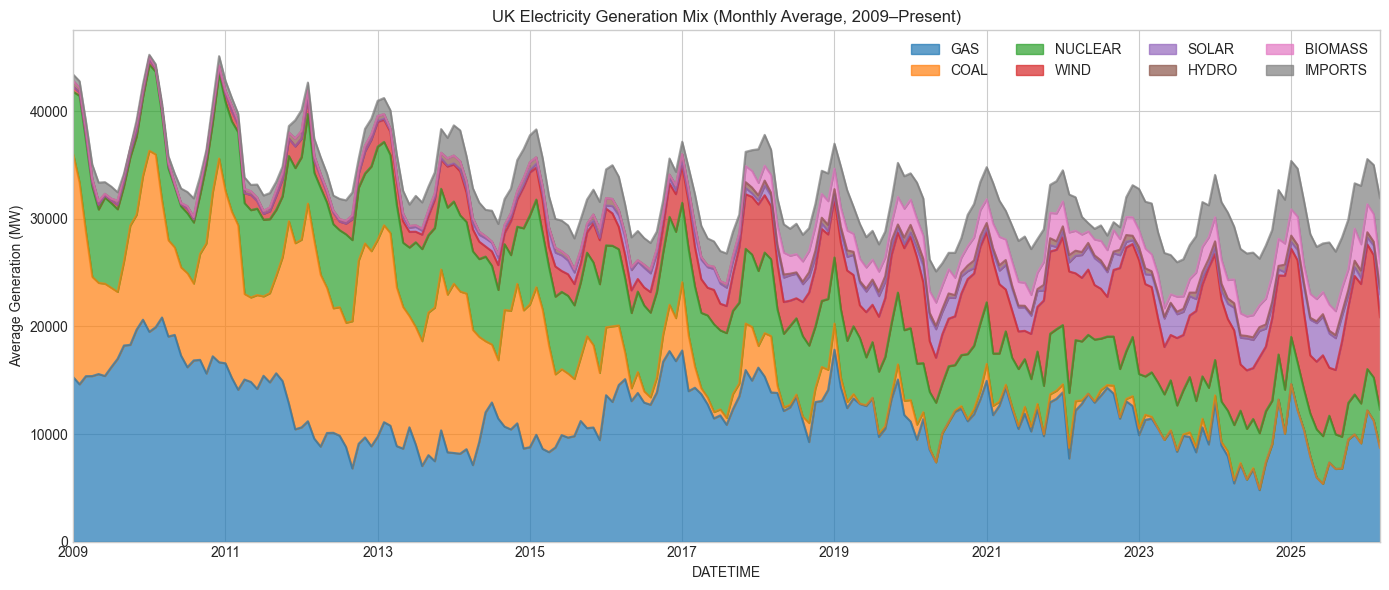

In [23]:
# Resample to monthly averages for cleaner trends
fuel_cols = ['GAS', 'COAL', 'NUCLEAR', 'WIND', 'SOLAR', 'HYDRO', 'BIOMASS', 'IMPORTS']
monthly = gen.set_index('DATETIME')[fuel_cols].resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 6))
monthly.plot.area(ax=ax, alpha=0.7)
ax.set_ylabel('Average Generation (MW)')
ax.set_title('UK Electricity Generation Mix (Monthly Average, 2009–Present)')
ax.legend(loc='upper right', ncol=4)
plt.tight_layout()
plt.show()

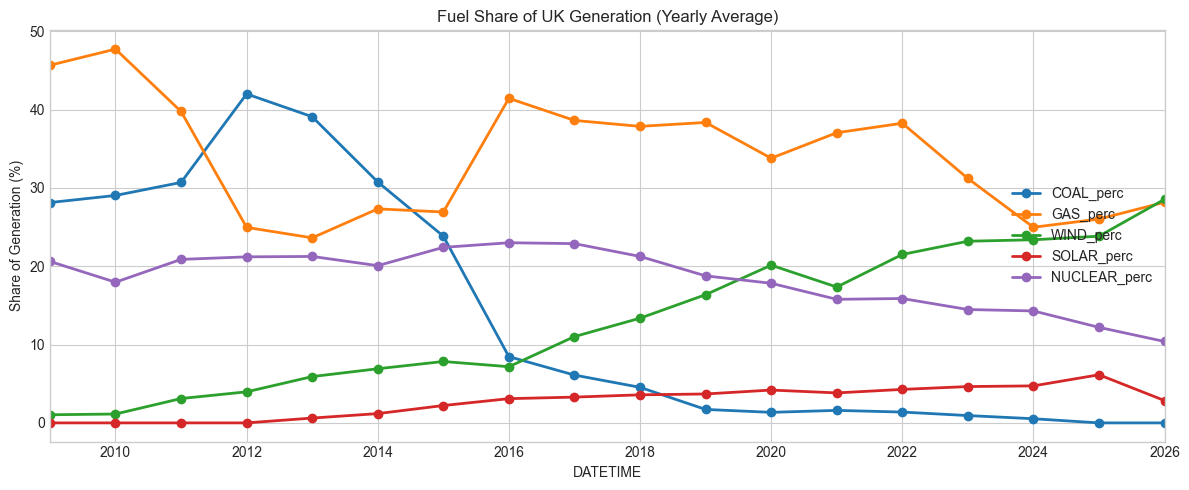

In [24]:
# Coal's decline and wind's rise
yearly_pct = gen.set_index('DATETIME')[['COAL_perc', 'GAS_perc', 'WIND_perc', 'SOLAR_perc', 'NUCLEAR_perc']].resample('YE').mean()

fig, ax = plt.subplots(figsize=(12, 5))
yearly_pct.plot(ax=ax, marker='o', linewidth=2)
ax.set_ylabel('Share of Generation (%)')
ax.set_title('Fuel Share of UK Generation (Yearly Average)')
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

### 1.2 Carbon Intensity Trend
Has the grid gotten cleaner over time?

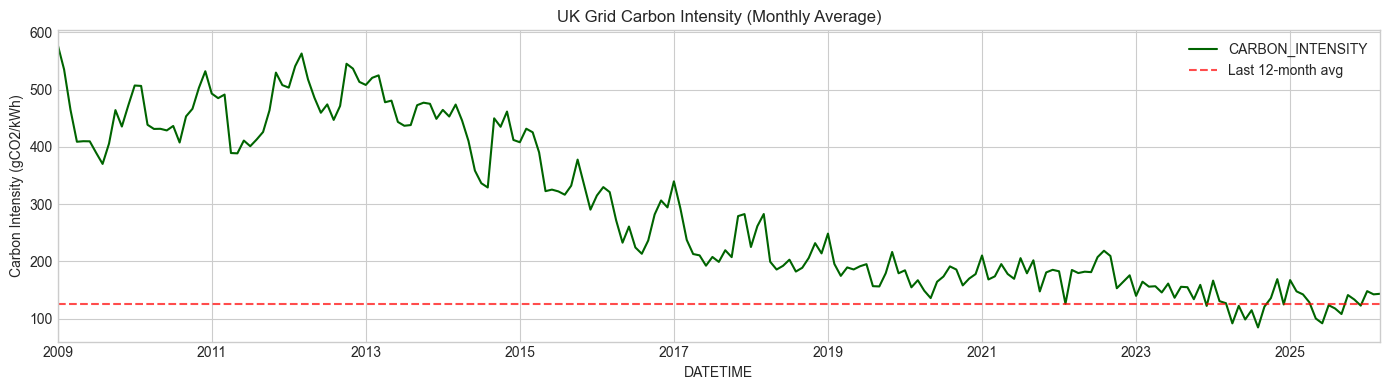

In [25]:
monthly_ci = gen.set_index('DATETIME')['CARBON_INTENSITY'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_ci.plot(ax=ax, color='darkgreen', linewidth=1.5)
ax.set_ylabel('Carbon Intensity (gCO2/kWh)')
ax.set_title('UK Grid Carbon Intensity (Monthly Average)')
ax.axhline(y=monthly_ci.iloc[-12:].mean(), color='red', linestyle='--', alpha=0.7, label='Last 12-month avg')
ax.legend()
plt.tight_layout()
plt.show()

### 1.3 Daily Generation Patterns
How does the fuel mix change throughout a typical day?

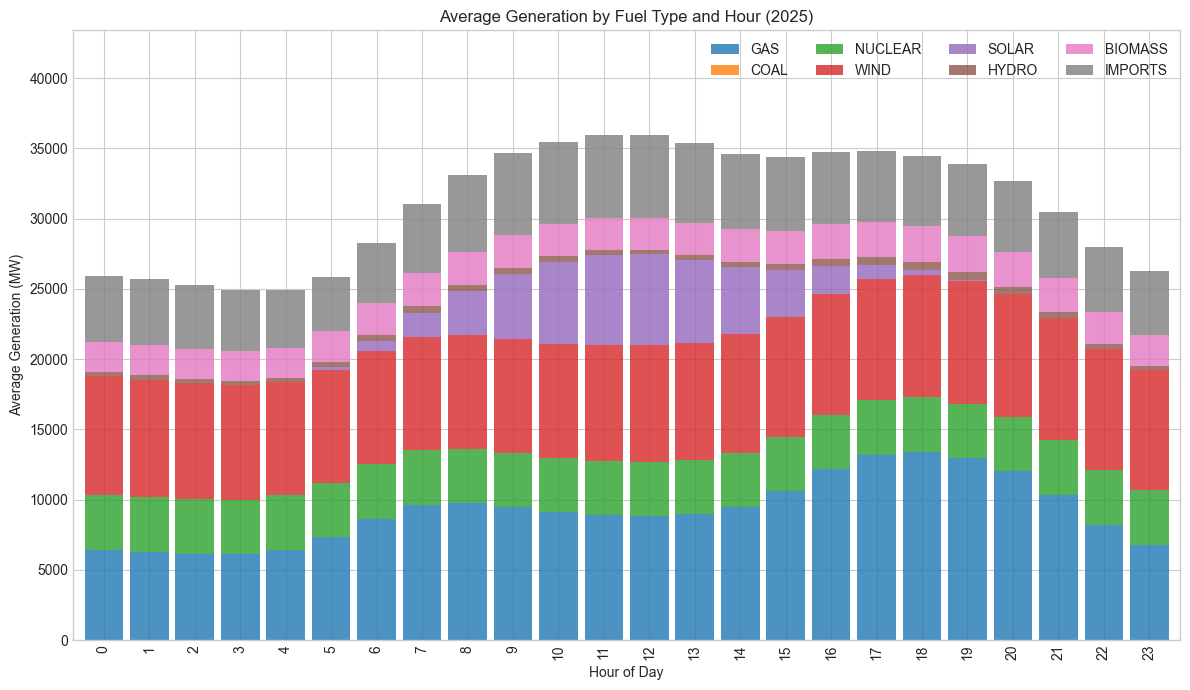

In [26]:
# Use last full year of data
recent = gen[gen['DATETIME'] >= '2025-01-01'].copy()
recent['hour'] = recent['DATETIME'].dt.hour

hourly_avg = recent.groupby('hour')[fuel_cols].mean()

fig, ax = plt.subplots(figsize=(12, 7))
hourly_avg.plot.bar(stacked=True, ax=ax, alpha=0.8, width=0.85)
ax.set_ylabel('Average Generation (MW)')
ax.set_xlabel('Hour of Day')
ax.set_title('Average Generation by Fuel Type and Hour (2025)')
ax.legend(loc='upper right', ncol=4)
# Add some headroom so the legend doesn't overlap the bars
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.15)
plt.tight_layout()
plt.show()

In [27]:
# --- Section 1 Summary Table ---
# Yearly average fuel shares (first vs last full year)
first_year = gen[gen['DATETIME'].dt.year == 2009]
last_year = gen[gen['DATETIME'].dt.year == 2025]

summary_fuels = pd.DataFrame({
    '2009 Avg MW': first_year[fuel_cols].mean().round(0),
    '2009 Share %': (first_year[fuel_cols].mean() / first_year['GENERATION'].mean() * 100).round(1),
    '2025 Avg MW': last_year[fuel_cols].mean().round(0),
    '2025 Share %': (last_year[fuel_cols].mean() / last_year['GENERATION'].mean() * 100).round(1),
})
print('=== Generation Mix: 2009 vs 2025 ===')
print(summary_fuels.to_string())

print(f'\nCarbon Intensity (monthly avg):')
print(f'  2009 mean: {monthly_ci.iloc[:12].mean():.0f} gCO2/kWh')
print(f'  Last 12 months mean: {monthly_ci.iloc[-12:].mean():.0f} gCO2/kWh')
print(f'  Reduction: {((1 - monthly_ci.iloc[-12:].mean() / monthly_ci.iloc[:12].mean()) * 100):.0f}%')

print(f'\nCoal generation in 2025: {last_year["COAL"].sum():.0f} MW total (effectively zero)')
print(f'UK last coal plant (Ratcliffe-on-Soar) closed September 2024')

=== Generation Mix: 2009 vs 2025 ===
         2009 Avg MW  2009 Share %  2025 Avg MW  2025 Share %
GAS          16825.0          44.8       8825.0          26.7
COAL         11278.0          30.0          0.0           0.0
NUCLEAR       7420.0          19.7       3899.0          11.8
WIND           380.0           1.0       7848.0          23.8
SOLAR            0.0           0.0       2130.0           6.5
HYDRO          406.0           1.1        384.0           1.2
BIOMASS          0.0           0.0       2275.0           6.9
IMPORTS        763.0           2.0       5021.0          15.2

Carbon Intensity (monthly avg):
  2009 mean: 445 gCO2/kWh
  Last 12 months mean: 125 gCO2/kWh
  Reduction: 72%

Coal generation in 2025: 246 MW total (effectively zero)
UK last coal plant (Ratcliffe-on-Soar) closed September 2024


## 2. Historic Demand

In [28]:
demand = pd.read_csv(DATA_RAW / 'historic_demand.csv')

# Parse the text date format (e.g., "01-JAN-2020")
demand['SETTLEMENT_DATE'] = pd.to_datetime(demand['SETTLEMENT_DATE'], format='mixed', dayfirst=True)

# Create a proper datetime from date + settlement period (each period = 30 mins)
demand['DATETIME'] = demand['SETTLEMENT_DATE'] + pd.to_timedelta((demand['SETTLEMENT_PERIOD'] - 1) * 30, unit='min')
demand = demand.sort_values('DATETIME').reset_index(drop=True)

print(f'Shape: {demand.shape}')
print(f'Date range: {demand["DATETIME"].min()} to {demand["DATETIME"].max()}')
print(f'\nMissing values:')
missing = demand.isnull().sum()
print(missing[missing > 0])
demand.head()

Shape: (105216, 25)
Date range: 2020-01-01 00:00:00 to 2025-12-31 23:30:00

Missing values:
SCOTTISH_TRANSFER    52608
dtype: int64


,_id,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,...,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,_year,SCOTTISH_TRANSFER,DATETIME
0,1,2020-01-01,1,26340,27153,23821,1073,6465,0,13040,...,-151,-47,854,0,0,0,0,2020,NaN,2020-01-01 00:00:00
1,2,2020-01-01,2,26921,27684,24393,1020,6465,0,13040,...,-146,0,854,0,0,0,0,2020,NaN,2020-01-01 00:30:00
2,3,2020-01-01,3,26569,27240,24085,1010,6465,0,13040,...,-53,0,854,0,0,0,0,2020,NaN,2020-01-01 01:00:00
3,4,2020-01-01,4,25754,26435,23350,1043,6465,0,13040,...,-66,0,854,0,0,0,0,2020,NaN,2020-01-01 01:30:00
4,5,2020-01-01,5,25075,25824,22788,1001,6465,0,13040,...,-74,-60,854,0,0,0,0,2020,NaN,2020-01-01 02:00:00


In [29]:
demand[['ND', 'TSD', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION']].describe()

,ND,TSD,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION
count,105216.000000,105216.000000,105216.00000,105216.000000
mean,26770.071101,28737.562158,1887.19556,1578.623242
std,6218.029345,5933.031571,1212.99503,2484.232210
min,12803.000000,15297.000000,125.00000,0.000000
25%,21898.000000,24228.000000,912.00000,0.000000
50%,25883.500000,27808.500000,1557.00000,5.000000
75%,30709.250000,32383.000000,2625.00000,2526.000000
max,46433.000000,47760.000000,5962.00000,14044.000000


### 2.1 National Demand Over Time

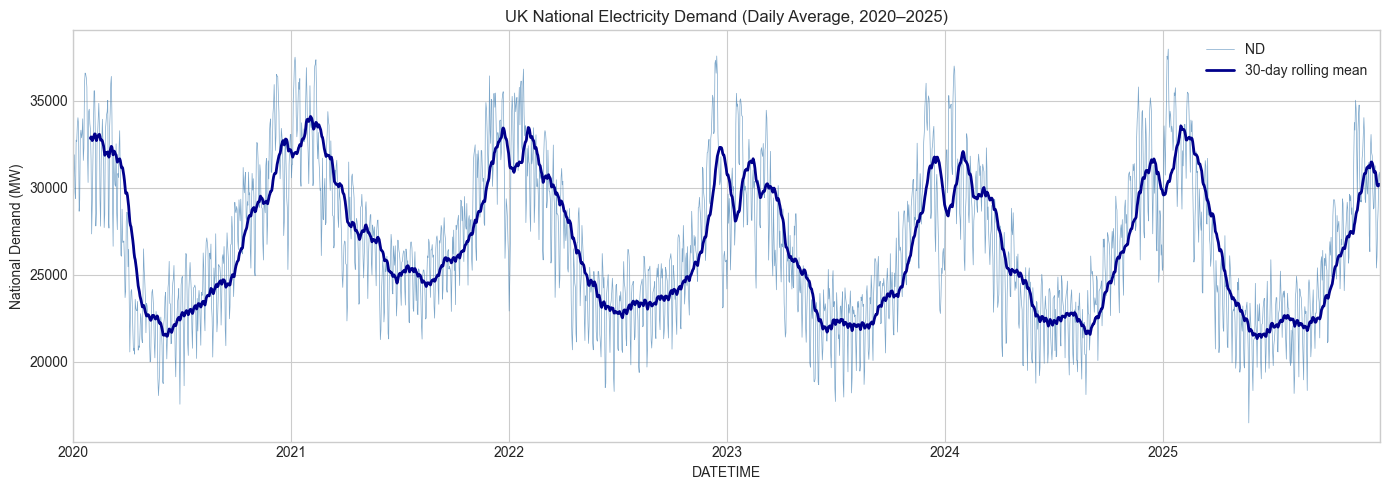

In [30]:
# Daily average demand
daily_demand = demand.set_index('DATETIME')['ND'].resample('D').mean()

fig, ax = plt.subplots(figsize=(14, 5))
daily_demand.plot(ax=ax, linewidth=0.5, alpha=0.7, color='steelblue')
daily_demand.rolling(30).mean().plot(ax=ax, linewidth=2, color='darkblue', label='30-day rolling mean')
ax.set_ylabel('National Demand (MW)')
ax.set_title('UK National Electricity Demand (Daily Average, 2020–2025)')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Seasonal and Weekly Patterns

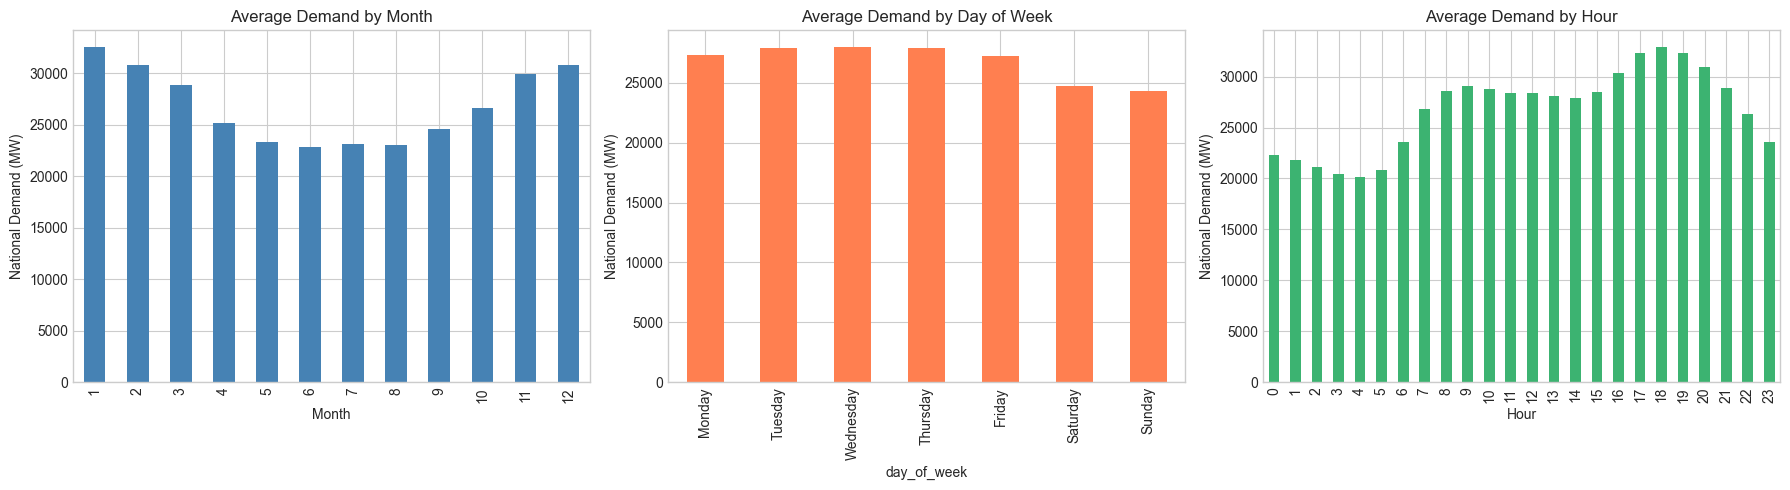

In [31]:
demand['month'] = demand['DATETIME'].dt.month
demand['day_of_week'] = demand['DATETIME'].dt.day_name()
demand['hour'] = demand['DATETIME'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly pattern
demand.groupby('month')['ND'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Demand by Month')
axes[0].set_ylabel('National Demand (MW)')
axes[0].set_xlabel('Month')

# Day of week pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
demand.groupby('day_of_week')['ND'].mean().reindex(day_order).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Demand by Day of Week')
axes[1].set_ylabel('National Demand (MW)')

# Hourly pattern
demand.groupby('hour')['ND'].mean().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Average Demand by Hour')
axes[2].set_ylabel('National Demand (MW)')
axes[2].set_xlabel('Hour')

plt.tight_layout()
plt.show()

### 2.3 Demand Heatmap: Hour vs Month
This shows how demand varies by time of day across seasons.

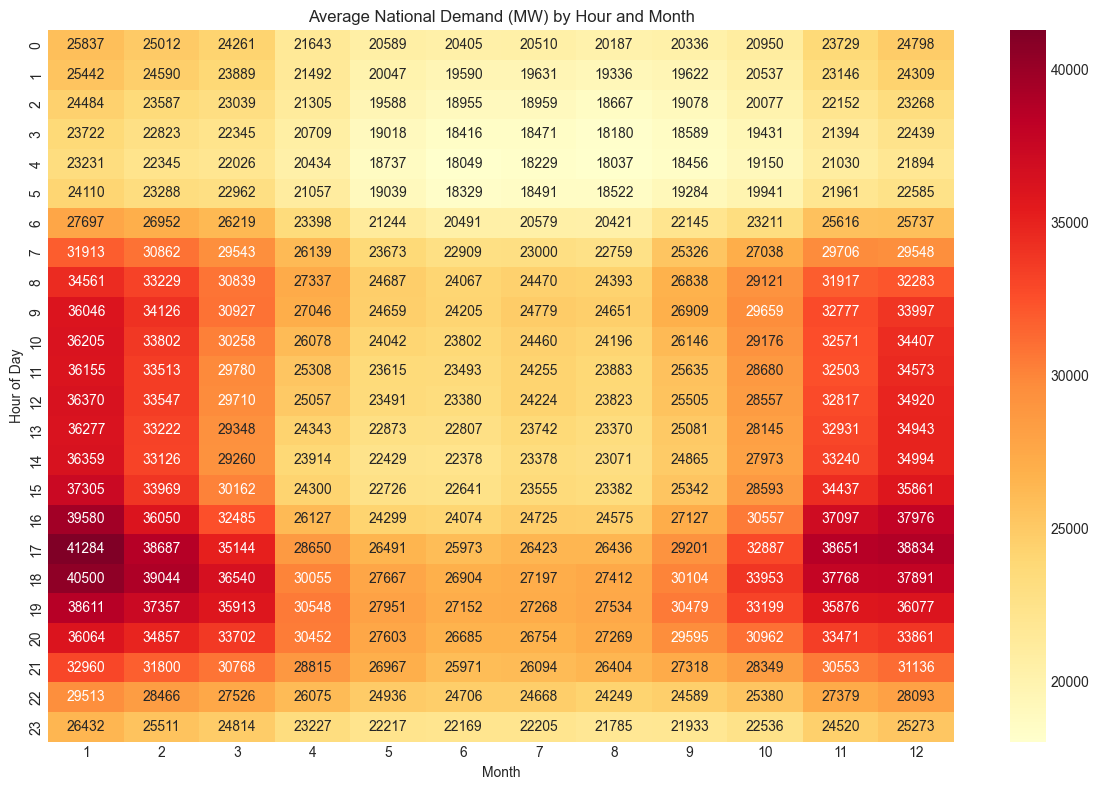

In [32]:
heatmap_data = demand.pivot_table(values='ND', index='hour', columns='month', aggfunc='mean')

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax)
ax.set_title('Average National Demand (MW) by Hour and Month')
ax.set_ylabel('Hour of Day')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

### 2.4 Embedded Renewables Growth

In [33]:
# --- Section 2 Summary Table ---
print('=== Historic Demand Summary ===')
print(f'Date range: {demand["DATETIME"].min()} to {demand["DATETIME"].max()}')
print(f'Records: {len(demand):,}')
print(f'\nNational Demand (ND) stats:')
print(f'  Mean: {demand["ND"].mean():,.0f} MW')
print(f'  Min:  {demand["ND"].min():,.0f} MW')
print(f'  Max:  {demand["ND"].max():,.0f} MW')
print(f'  Std:  {demand["ND"].std():,.0f} MW')

print(f'\nAverage demand by month (MW):')
monthly_demand = demand.groupby('month')['ND'].mean()
for m in range(1, 13):
    print(f'  Month {m:2d}: {monthly_demand[m]:,.0f}')

print(f'\nAverage demand by day of week (MW):')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_demand_dow = demand.groupby('day_of_week')['ND'].mean().reindex(day_order)
for day in day_order:
    print(f'  {day:10s}: {daily_demand_dow[day]:,.0f}')

print(f'\nEmbedded renewables (monthly avg, first vs last 12 months):')
first_12 = monthly_renewables.iloc[:12].mean()
last_12 = monthly_renewables.iloc[-12:].mean()
print(f'  Wind:  {first_12["EMBEDDED_WIND_GENERATION"]:.0f} -> {last_12["EMBEDDED_WIND_GENERATION"]:.0f} MW')
print(f'  Solar: {first_12["EMBEDDED_SOLAR_GENERATION"]:.0f} -> {last_12["EMBEDDED_SOLAR_GENERATION"]:.0f} MW')

=== Historic Demand Summary ===
Date range: 2020-01-01 00:00:00 to 2025-12-31 23:30:00
Records: 105,216

National Demand (ND) stats:
  Mean: 26,770 MW
  Min:  12,803 MW
  Max:  46,433 MW
  Std:  6,218 MW

Average demand by month (MW):
  Month  1: 32,527
  Month  2: 30,824
  Month  3: 28,816
  Month  4: 25,146
  Month  5: 23,274
  Month  6: 22,815
  Month  7: 23,169
  Month  8: 23,023
  Month  9: 24,563
  Month 10: 26,580
  Month 11: 29,884
  Month 12: 30,821

Average demand by day of week (MW):
  Monday    : 27,330
  Tuesday   : 27,929
  Wednesday : 27,987
  Thursday  : 27,902
  Friday    : 27,215
  Saturday  : 24,702
  Sunday    : 24,320

Embedded renewables (monthly avg, first vs last 12 months):
  Wind:  2082 -> 1956 MW
  Solar: 1373 -> 2122 MW


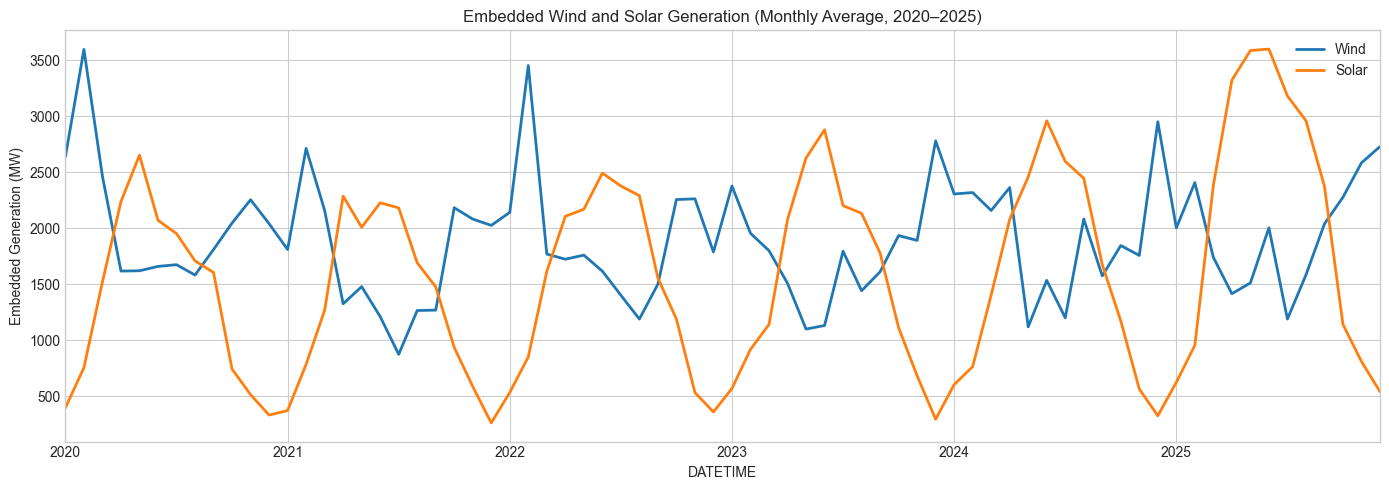

In [34]:
monthly_renewables = demand.set_index('DATETIME')[['EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION']].resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_renewables.plot(ax=ax, linewidth=2)
ax.set_ylabel('Embedded Generation (MW)')
ax.set_title('Embedded Wind and Solar Generation (Monthly Average, 2020–2025)')
ax.legend(['Wind', 'Solar'])
plt.tight_layout()
plt.show()

## 3. Carbon Intensity (Forecast vs Actual)

In [35]:
# --- Section 3 Summary Table ---
print('=== Carbon Intensity Forecast Accuracy ===')
print(f'Records: {len(ci_valid):,} (after dropping {ci["forecast"].isna().sum()} missing forecasts)')
print(f'Date range: {ci["from"].min()} to {ci["from"].max()}')
print(f'\nForecast performance:')
print(f'  Mean Absolute Error: {ci_valid["abs_error"].mean():.1f} gCO2/kWh')
print(f'  Mean Error (bias):   {ci_valid["error"].mean():+.1f} gCO2/kWh')
print(f'  Correlation:         {ci_valid["forecast"].corr(ci_valid["actual"]):.4f}')
print(f'  Median Error:        {ci_valid["error"].median():+.1f} gCO2/kWh')
print(f'\nIntensity index distribution:')
for idx, count in ci['index'].value_counts().items():
    print(f'  {idx:10s}: {count:,} ({count/len(ci)*100:.1f}%)')

=== Carbon Intensity Forecast Accuracy ===
Records: 38,958 (after dropping 45 missing forecasts)
Date range: 2023-12-31 23:30:00+00:00 to 2026-03-22 23:30:00+00:00

Forecast performance:
  Mean Absolute Error: 9.6 gCO2/kWh
  Mean Error (bias):   +0.1 gCO2/kWh
  Correlation:         0.9748
  Median Error:        +0.0 gCO2/kWh

Intensity index distribution:
  low       : 15,430 (39.6%)
  moderate  : 15,333 (39.3%)
  high      : 7,339 (18.8%)
  very high : 713 (1.8%)
  very low  : 188 (0.5%)


In [36]:
ci = pd.read_csv(DATA_RAW / 'carbon_intensity.csv')
ci['from'] = pd.to_datetime(ci['from'])
ci = ci.sort_values('from').reset_index(drop=True)

print(f'Shape: {ci.shape}')
print(f'Date range: {ci["from"].min()} to {ci["from"].max()}')
print(f'\nMissing values:')
print(ci.isnull().sum())
print(f'\nIntensity index distribution:')
print(ci['index'].value_counts())
ci.head()

Shape: (39003, 5)
Date range: 2023-12-31 23:30:00+00:00 to 2026-03-22 23:30:00+00:00

Missing values:
from         0
to           0
forecast    45
actual       0
index        0
dtype: int64

Intensity index distribution:
index
low          15430
moderate     15333
high          7339
very high      713
very low       188
Name: count, dtype: int64


,from,to,forecast,actual,index
0,2023-12-31 23:30:00+00:00,2024-01-01T00:00Z,68.0,63,low
1,2024-01-01 00:00:00+00:00,2024-01-01T00:30Z,64.0,64,low
2,2024-01-01 00:30:00+00:00,2024-01-01T01:00Z,62.0,64,low
3,2024-01-01 01:00:00+00:00,2024-01-01T01:30Z,65.0,62,low
4,2024-01-01 01:30:00+00:00,2024-01-01T02:00Z,61.0,71,low


Forecast vs Actual (n=38,958):
  Mean Absolute Error: 9.6 gCO2/kWh
  Mean Error (bias):   0.1 gCO2/kWh
  Correlation:         0.9748


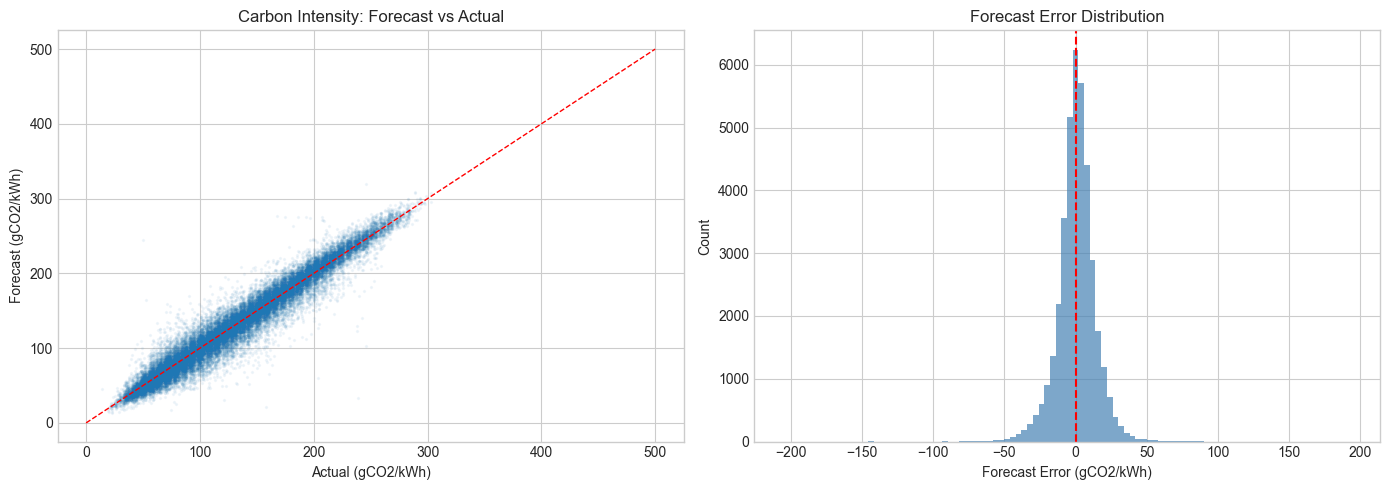

In [37]:
# Forecast accuracy
ci_valid = ci.dropna(subset=['forecast', 'actual'])
ci_valid = ci_valid.copy()
ci_valid['error'] = ci_valid['forecast'] - ci_valid['actual']
ci_valid['abs_error'] = ci_valid['error'].abs()

print(f'Forecast vs Actual (n={len(ci_valid):,}):')
print(f'  Mean Absolute Error: {ci_valid["abs_error"].mean():.1f} gCO2/kWh')
print(f'  Mean Error (bias):   {ci_valid["error"].mean():.1f} gCO2/kWh')
print(f'  Correlation:         {ci_valid["forecast"].corr(ci_valid["actual"]):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: forecast vs actual
axes[0].scatter(ci_valid['actual'], ci_valid['forecast'], alpha=0.05, s=2)
axes[0].plot([0, 500], [0, 500], 'r--', linewidth=1)
axes[0].set_xlabel('Actual (gCO2/kWh)')
axes[0].set_ylabel('Forecast (gCO2/kWh)')
axes[0].set_title('Carbon Intensity: Forecast vs Actual')

# Error distribution
axes[1].hist(ci_valid['error'], bins=100, alpha=0.7, color='steelblue', edgecolor='none')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Forecast Error (gCO2/kWh)')
axes[1].set_ylabel('Count')
axes[1].set_title('Forecast Error Distribution')

plt.tight_layout()
plt.show()

In [38]:
# Daily peak demand
daily_peak = demand.groupby(demand['DATETIME'].dt.date)['ND'].max().reset_index()
daily_peak.columns = ['date', 'peak_demand']
daily_peak['date'] = pd.to_datetime(daily_peak['date'])
daily_peak['month'] = daily_peak['date'].dt.month

# Z-score within each month to account for seasonality
daily_peak['z_score'] = daily_peak.groupby('month')['peak_demand'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Flag anomalies (|z| > 2.5)
anomalies = daily_peak[daily_peak['z_score'].abs() > 2.5].sort_values('z_score')

print(f'Anomalous days (|z-score| > 2.5): {len(anomalies)}')
print('\nLowest demand days (potential holidays/events):')
print(anomalies[anomalies['z_score'] < 0][['date', 'peak_demand', 'z_score']].head(10).to_string(index=False))
print('\nHighest demand days (cold snaps/events):')
print(anomalies[anomalies['z_score'] > 0][['date', 'peak_demand', 'z_score']].tail(10).to_string(index=False))

Anomalous days (|z-score| > 2.5): 16

Lowest demand days (potential holidays/events):
      date  peak_demand   z_score
2022-01-01        31054 -3.647174
2023-01-01        32628 -3.091910
2023-07-01        21680 -2.847382
2023-01-07        33447 -2.802989
2024-03-31        28138 -2.783691
2023-07-29        21910 -2.737072
2025-01-01        34021 -2.600498
2022-01-02        34078 -2.580390
2022-10-01        27323 -2.576222
2023-01-14        34193 -2.539821

Highest demand days (cold snaps/events):
      date  peak_demand  z_score
2020-09-29        36505 2.640271
2020-09-30        36631 2.697717
2021-04-07        37842 2.746177
2020-03-05        45490 2.748882
2020-09-28        37185 2.950297


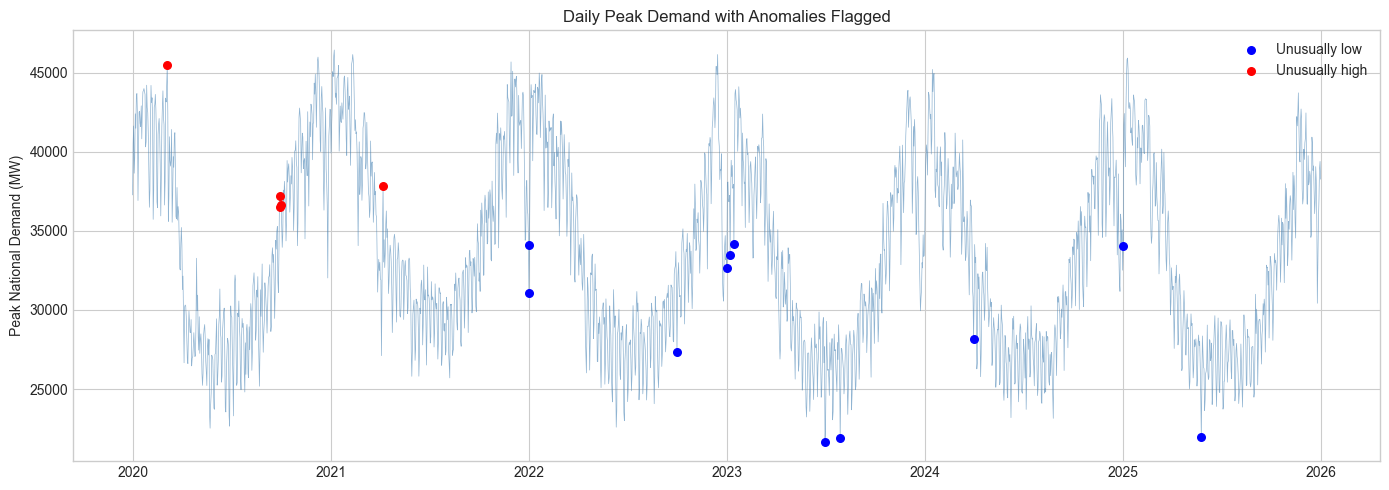

In [39]:
# Visualise anomalies
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_peak['date'], daily_peak['peak_demand'], linewidth=0.5, alpha=0.6, color='steelblue')

low_anom = anomalies[anomalies['z_score'] < 0]
high_anom = anomalies[anomalies['z_score'] > 0]
ax.scatter(low_anom['date'], low_anom['peak_demand'], color='blue', s=30, zorder=5, label='Unusually low')
ax.scatter(high_anom['date'], high_anom['peak_demand'], color='red', s=30, zorder=5, label='Unusually high')

ax.set_ylabel('Peak National Demand (MW)')
ax.set_title('Daily Peak Demand with Anomalies Flagged')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Summary & Next Steps

### Key Observations

**Dataset completeness:**
- Generation mix: 301,956 records (hourly), 2009-present, no missing values.
- Historic demand: 105,216 records (half-hourly), 2020-2025, one column with missing values (SCOTTISH_TRANSFER - 50% missing, likely due to later introduction).
- Carbon intensity: 39,003 records (half-hourly), 2024-present, 45 missing forecast values.

**UK energy transition (Section 1.1 & 1.2):**
- Coal has been completely eliminated from the UK generation mix - from 30.0% share in 2009 to 0.0% in 2025, following the closure of the UK's last coal plant (Ratcliffe-on-Soar) in September 2024.
- Wind has grown from 1.0% to 23.8%, becoming the second largest generation source behind gas.
- Gas remains the largest single source but has declined from 44.8% to 26.7%.
- Imports have grown significantly from 2.0% to 15.2%, reflecting increased interconnector capacity.
- Carbon intensity has fallen 72% - from 445 gCO2/kWh in 2009 to 125 gCO2/kWh in the last 12 months. The steepest decline occurred between 2015-2019 during rapid coal phase-out.

**Daily generation patterns (Section 1.3):**
- In 2025, peak generation occurs at 11:00 (35,942 MW) driven by gas (24.7%), wind (22.9%), and solar (18.0%).
- Trough generation occurs at 4:00 (24,886 MW) where wind dominates at 32.4% - the grid effectively runs on wind overnight.
- Coal contributes 0% at every hour - confirming its complete elimination.

**Demand patterns (Sections 2.1-2.3):**
- Strong seasonal pattern: January averages 32,527 MW vs June at 22,815 MW.
- Clear weekday/weekend split: weekdays average ~27,700 MW vs weekends ~24,500 MW.
- Hourly peak at 18:00 (32,894 MW), trough at 4:00 (20,126 MW) - a 1.63x ratio.
- Heatmap extremes: highest demand is 41,284 MW (5pm, January) vs lowest 18,037 MW (4am, August) - a 2.3x range across the full year.
- Average demand has been gradually declining from 28,345 MW (2021) to 26,158 MW (2025), likely reflecting efficiency gains and growth in embedded generation.

**Embedded renewables growth (Section 2.4):**
- Embedded solar has grown from ~1,373 MW to ~2,122 MW average over the period.
- Embedded wind has remained relatively stable (~2,000 MW average).
- This growth makes demand harder to forecast from central generation data alone.

**Carbon Intensity API forecast accuracy (Section 3):**
- Excellent accuracy: MAE of 9.6 gCO2/kWh, near-zero bias (+0.1), correlation of 0.9748.
- The grid is classified as "low" or "moderate" intensity 79% of the time, "very high" only 1.8%.

**Anomaly detection (Section 4):**
- 16 days flagged with |z-score| > 2.5 (seasonally adjusted).
- Low-demand anomalies cluster around public holidays (Jan 1 across multiple years, Easter).
- High-demand anomalies concentrate in early-mid 2020 (pre-COVID cold weather events).
- These anomalous days are prime candidates for the RAG pipeline to explain using NESO/Ofgem reports.

### Implications for Forecasting (Phase 2)

- Strong seasonal, weekly, and hourly patterns suggest time-based features (hour, day-of-week, month) will be important predictors.
- Wind and solar variability - especially the overnight reliance on wind - means weather data could be a valuable external feature.
- The shift away from dispatchable fossil fuels toward intermittent renewables makes demand forecasting increasingly important for grid stability - directly relevant to energy companies like Ithaca Energy.

### Next Steps

- **Notebook 02:** Feature engineering and demand forecasting model (XGBoost/Prophet).
- **Notebook 03:** RAG pipeline - ingest NESO/Ofgem PDF reports, build retrieval system to explain anomalies.
- **Integration:** Connect anomaly detection to RAG-based context retrieval for a complete "UK Energy Intelligence Assistant".